<a href="https://colab.research.google.com/github/lathikasuriyamoorthy-29/trendpulse-lathikasuriyamoorthy/blob/main/task4_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving trends_analyzed (3).csv to trends_analyzed (3).csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (88, 9)


In [4]:
df.head()

,post_id,title,category,score,num_comments,author,collected_at,engagement,is_popular
0,49959869,Powerless F1 drivers frustrated by Bahrain F1 ...,sports,176,109,llm_nerd,2026-10-05 06:48:56.805436,0.615819,False
1,49925261,Sudo – A dedicated music player designed aroun...,sports,52,79,kapsteur,2026-10-05 06:49:51.581926,1.490566,False
2,49917102,Steelers ex-coach Mike Tomlin has been buildin...,sports,31,1,Vaslo,2026-10-05 06:50:38.306164,0.031250,False
3,49957116,Turn off Apple Intelligence on macOS 27 and ge...,science,510,319,privacyisntdead,2026-10-05 06:50:43.766219,0.624266,False
4,49956035,Incentives in Academic Research,science,47,43,zero_k,2026-10-05 06:50:48.459475,0.895833,False


In [5]:
os.makedirs("outputs", exist_ok=True)

In [6]:
top_10 = df.nlargest(10, "score").copy()

In [7]:
top_10["short_title"] = top_10["title"].apply(
    lambda title: title[:50] + "..." if len(title) > 50 else title)

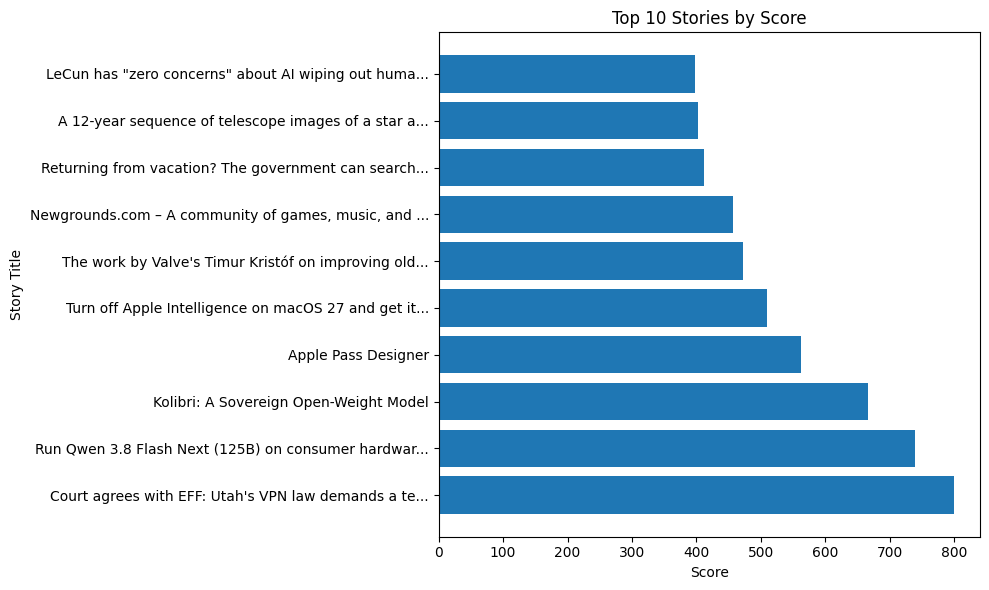

In [8]:
plt.figure(figsize=(10, 6))

plt.barh(top_10["short_title"], top_10["score"])

plt.xlabel("Score")
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score")

plt.tight_layout()

plt.savefig("outputs/chart1_top_stories.png")

plt.show()

In [9]:
category_counts = df["category"].value_counts()

print(category_counts)

category
science          25
technology       25
worldnews        22
entertainment    13
sports            3
Name: count, dtype: int64


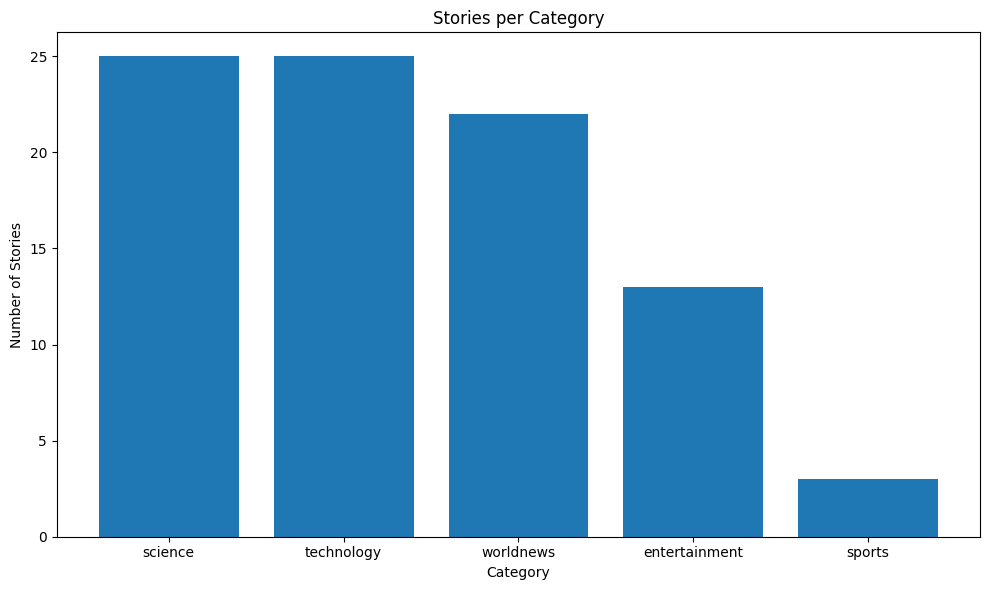

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title("Stories per Category")

plt.tight_layout()

plt.savefig("outputs/chart2_categories.png")

plt.show()

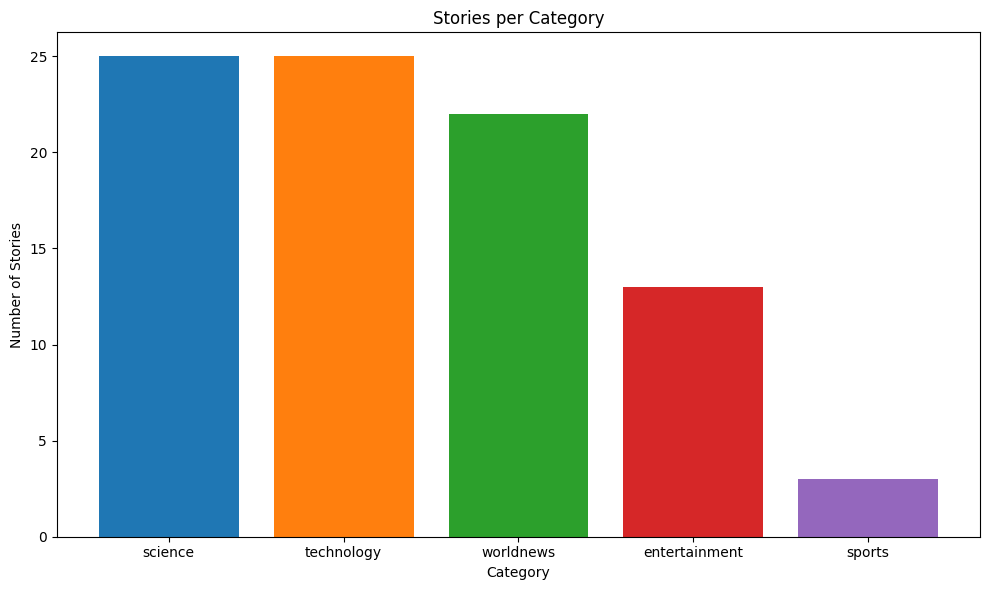

In [11]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(range(len(category_counts)))

plt.bar(
    category_counts.index,
    category_counts.values,
    color=colors
)

plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title("Stories per Category")

plt.tight_layout()

plt.savefig("outputs/chart2_categories.png")

plt.show()

In [12]:
popular = df[df["is_popular"] == True]

not_popular = df[df["is_popular"] == False]

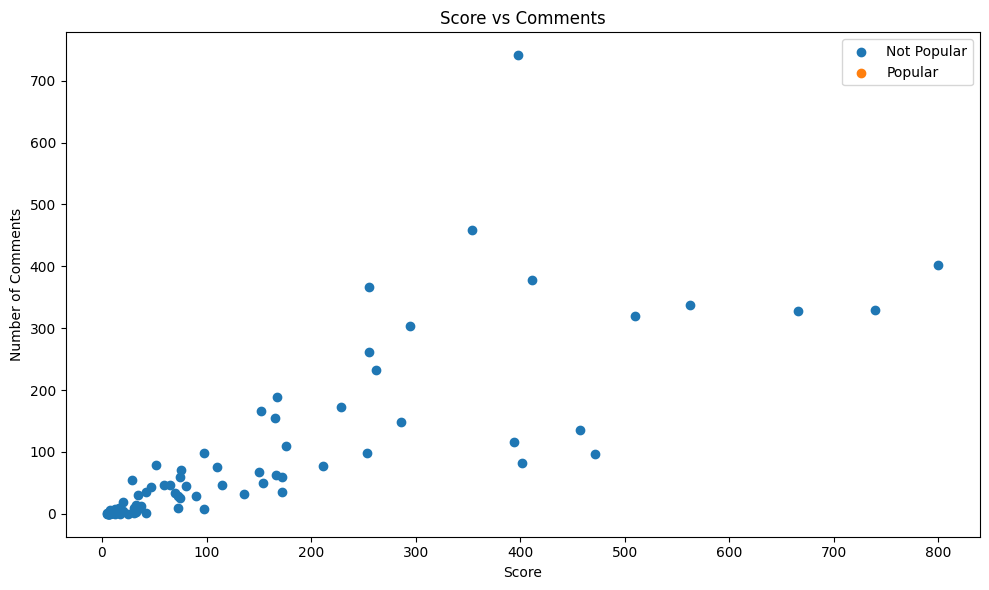

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    not_popular["score"],
    not_popular["num_comments"],
    label="Not Popular"
)

plt.scatter(
    popular["score"],
    popular["num_comments"],
    label="Popular"
)

plt.xlabel("Score")
plt.ylabel("Number of Comments")
plt.title("Score vs Comments")

plt.legend()

plt.tight_layout()

plt.savefig("outputs/chart3_scatter.png")

plt.show()

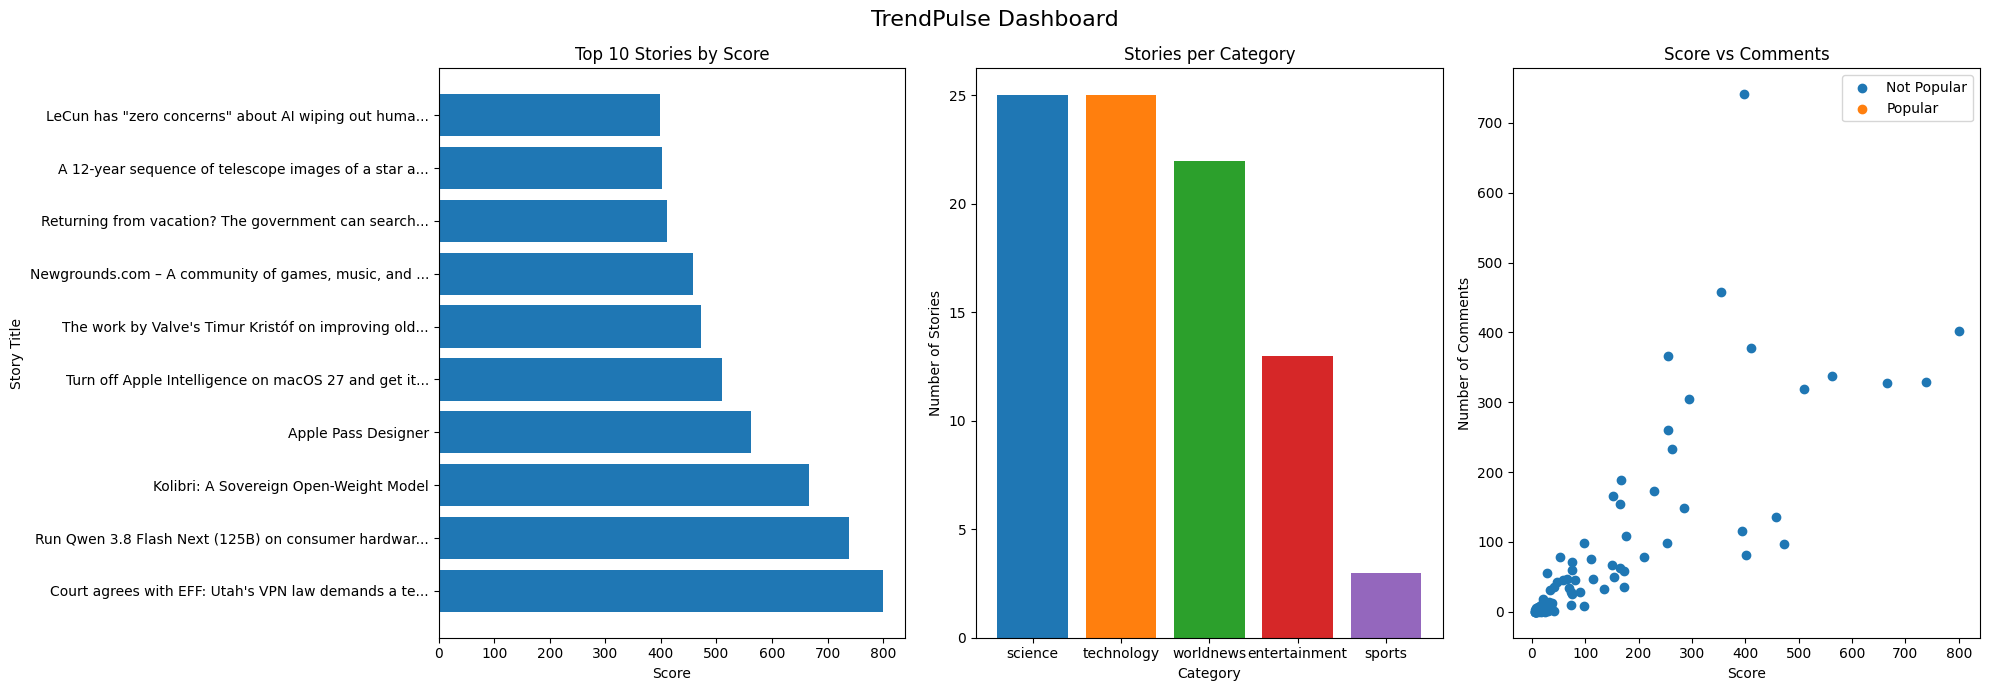

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))


# Chart 1 — Top 10 Stories
axes[0].barh(
    top_10["short_title"],
    top_10["score"]
)

axes[0].set_xlabel("Score")
axes[0].set_ylabel("Story Title")
axes[0].set_title("Top 10 Stories by Score")


# Chart 2 — Stories per Category
axes[1].bar(
    category_counts.index,
    category_counts.values,
    color=plt.cm.tab10(range(len(category_counts)))
)

axes[1].set_xlabel("Category")
axes[1].set_ylabel("Number of Stories")
axes[1].set_title("Stories per Category")


# Chart 3 — Score vs Comments
axes[2].scatter(
    not_popular["score"],
    not_popular["num_comments"],
    label="Not Popular"
)

axes[2].scatter(
    popular["score"],
    popular["num_comments"],
    label="Popular"
)

axes[2].set_xlabel("Score")
axes[2].set_ylabel("Number of Comments")
axes[2].set_title("Score vs Comments")
axes[2].legend()


# Overall title
fig.suptitle("TrendPulse Dashboard", fontsize=16)

plt.tight_layout()

plt.savefig("outputs/dashboard.png")

plt.show()

In [15]:
import os

print(os.listdir("outputs"))

['chart1_top_stories.png', 'dashboard.png', 'chart3_scatter.png', 'chart2_categories.png']


In [16]:
from google.colab import files

files.download("outputs/chart1_top_stories.png")
files.download("outputs/chart2_categories.png")
files.download("outputs/chart3_scatter.png")
files.download("outputs/dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>